In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt

color=['0.3', '0.5', '0.7', '0.9']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

pd.set_option('display.max_rows', 6)
from IPython.display import HTML
import networkx as nx

In [2]:
# =============================================================================
#  APPLY THEME  --  Beamer "Madrid" look. Re-run any time to refresh styling.
# =============================================================================
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="03b-Checkpoint-Quiz.ipynb",
)
import course_helpers as chh

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 7 cell(s):
 cell_index slide_id                                  tags
          0          slide_hide_prompt, slide_remove_input
          1          slide_hide_prompt, slide_remove_input
          2          slide_hide_prompt, slide_remove_input
          9          slide_hide_prompt, slide_remove_input
         11          slide_hide_prompt, slide_remove_input
         13          slide_hide_prompt, slide_remove_input
         16          slide_hide_prompt, slide_remove_input


In [3]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# Checkpoint


<br>

<b style="color:#73000A;">Robert Pettis</b>
Fall 2026

## How This Works

- Nine questions, about fifteen minutes
- Read it, pick an answer, and be ready to say <b style="color:#73000A;">why</b>. I will call on people
- Being wrong here is the cheapest it will ever be. Wrong answers tell me what to teach again
- No notes, no laptops. Every question is about ideas, not arithmetic

### Question 1: The Aspirin

Your roommate has a headache. They take an aspirin, and an hour later the headache is gone. They tell you the aspirin worked.

What would you need to know to be sure?

- <b style="color:#73000A;">A.</b> Whether the headache came back later
- <b style="color:#73000A;">B.</b> How much aspirin they took
- <b style="color:#73000A;">C.</b> What would have happened to <i>this</i> roommate, this time, with no aspirin
- <b style="color:#73000A;">D.</b> Whether other people's headaches go away after aspirin

### Question 2: The Free Tutoring

The university offers free tutoring. Anyone can sign up. At the end of term, the students who used tutoring have lower grades than the students who did not.

Which is the most likely explanation?

- <b style="color:#73000A;">A.</b> The students who signed up were already struggling
- <b style="color:#73000A;">B.</b> Tutoring lowers grades
- <b style="color:#73000A;">C.</b> The sample is too small
- <b style="color:#73000A;">D.</b> Tutoring works, but only for students who do not need it

### Question 3: What the Coin Flip Buys

We run the tutoring program again, but this time a coin flip decides who is offered it.

Now the two groups are:

- <b style="color:#73000A;">A.</b> Identical to each other
- <b style="color:#73000A;">B.</b> Comparable on the things we measured and put in the model
- <b style="color:#73000A;">C.</b> Identical in their treated outcomes, $Y_1$
- <b style="color:#73000A;">D.</b> Comparable on average, including on things we never measured

### Question 4: Who It Worked For

A job training program raises earnings by \$2,000 on average. Split the trainees by schooling: for those without a high school diploma the program is worth \$5,000, and for college graduates it is worth about nothing.

The \$5,000 is:

- <b style="color:#73000A;">A.</b> The average earnings of trainees without a diploma
- <b style="color:#73000A;">B.</b> What the program did for each trainee without a diploma
- <b style="color:#73000A;">C.</b> The average effect among trainees without a diploma, a CATE
- <b style="color:#73000A;">D.</b> The average effect across every trainee, an ATE

### Question 5: Firefighters

Across cities, fires that had more firefighters on the scene also had more damage.

What explains the pattern?

- <b style="color:#73000A;">A.</b> Firefighters cause damage
- <b style="color:#73000A;">B.</b> Something causes both: bigger fires bring more firefighters and do more damage
- <b style="color:#73000A;">C.</b> Damage causes firefighters, so the arrow points the other way
- <b style="color:#73000A;">D.</b> It is a coincidence in the data

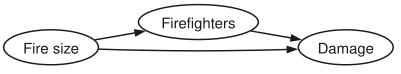

In [4]:
chh.draw_dag([("Fire size", "Firefighters"), ("Fire size", "Damage"),
              ("Firefighters", "Damage")])

### Question 6: The Restaurants

Think of every restaurant you have eaten at in this town. Among them, the cheap ones have surprisingly good food and the expensive ones are mostly mediocre. Across all the restaurants in town, price and quality have nothing to do with each other.

Why does the pattern show up in the places you have eaten?

- <b style="color:#73000A;">A.</b> Cheap restaurants work harder to keep customers coming back
- <b style="color:#73000A;">B.</b> You have not eaten at enough places
- <b style="color:#73000A;">C.</b> You only bother going somewhere that is cheap <i>or</i> good, so among the ones you have been to, the two trade off
- <b style="color:#73000A;">D.</b> Expensive restaurants charge for the room, not the food

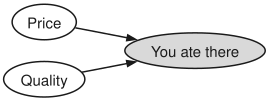

In [5]:
chh.draw_dag([("Price", "You ate there"), ("Quality", "You ate there")],
             boxed=("You ate there",))

### Question 7: The Job Training

A job training program is meant to raise earnings. An analyst estimates its effect on earnings while controlling for whether the person found a job.

What has that control done?

- <b style="color:#73000A;">A.</b> Blocked most of the effect, since finding a job is how training raises earnings
- <b style="color:#73000A;">B.</b> Removed confounding, so the estimate is now cleaner
- <b style="color:#73000A;">C.</b> Nothing much, since finding a job is measured after training
- <b style="color:#73000A;">D.</b> Made the estimate more precise without changing it

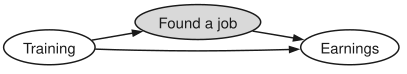

In [6]:
chh.draw_dag([("Training", "Found a job"), ("Found a job", "Earnings"),
              ("Training", "Earnings")], boxed=("Found a job",))

### Question 8: Put It Together

We want the effect of <b style="color:#73000A;">running regularly</b> on <b style="color:#73000A;">resting heart rate</b>. Four variables are available.

Which one should go into the model?

- <b style="color:#73000A;">A.</b> Fitness improvement over the year, measured after the running started
- <b style="color:#73000A;">B.</b> Whether the person finished a marathon this year, which running and a strong heart both make more likely
- <b style="color:#73000A;">C.</b> Age, which affects both how much people run and their resting heart rate
- <b style="color:#73000A;">D.</b> Weekly mileage in a running app, recorded only for people who own the app

### Question 9: The Coffee Study

A colleague wants the effect of <b style="color:#73000A;">coffee</b> on <b style="color:#73000A;">productivity</b>, and worries that people who sleep badly drink more coffee.

So they regress coffee on sleep, keep the leftover (the part of someone's coffee habit that sleep does not explain), and then regress productivity on that leftover <b style="color:#73000A;">alone</b>. Sleep never appears in the final model.

Is that final estimate still confounded by sleep?

- <b style="color:#73000A;">A.</b> Yes, because sleep is not in the final regression
- <b style="color:#73000A;">B.</b> No, the leftover coffee is uncorrelated with sleep by construction
- <b style="color:#73000A;">C.</b> Yes, unless sleep was randomly assigned
- <b style="color:#73000A;">D.</b> No, but only if sleep has no direct effect on productivity

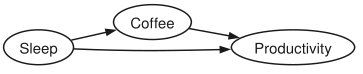

In [7]:
chh.draw_dag([("Sleep", "Coffee"), ("Sleep", "Productivity"),
              ("Coffee", "Productivity")])